In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def matriz_transicion(n=20, accion="avanzar"):
    """
    Construye la matriz de transición T de tamaño n×n para el filtro discreto
    """
    T = np.zeros((n, n))

    for i in range(n):
        if accion == "avanzar":
            if i == n - 1:
                T[n - 1, i] = 1.0
            elif i == n - 2:
                T[n - 2, i] = 0.25
                T[n - 1, i] = 0.75
            else:
                T[i,     i] = 0.25
                T[i + 1, i] = 0.50
                T[i + 2, i] = 0.25

        elif accion == "retroceder":
            if i == 0:
                T[0, i] = 1.0
            elif i == 1:
                T[1, i] = 0.25
                T[0, i] = 0.75
            else:
                T[i,     i] = 0.25
                T[i - 1, i] = 0.50
                T[i - 2, i] = 0.25

        else:
            raise ValueError("La acción debe ser 'avanzar' o 'retroceder'.")

    return T


In [9]:
def aplicar_accion(bel, T):
    """
    Paso de predicción del filtro de Bayes discreto
    """
    return T @ bel


In [10]:
n = 20

bel = np.hstack((np.zeros(10), [1.0], np.zeros(9)))

T_avanzar   = matriz_transicion(n, "avanzar")
T_retroceder = matriz_transicion(n, "retroceder")

assert np.allclose(T_avanzar.sum(axis=0),   1.0), "T_avanzar no es estocástica"
assert np.allclose(T_retroceder.sum(axis=0), 1.0), "T_retroceder no es estocástica"

for _ in range(9):
    bel = aplicar_accion(bel, T_avanzar)

for _ in range(3):
    bel = aplicar_accion(bel, T_retroceder)


In [11]:
celda_mas_probable = np.argmax(bel)
print("Belief final:")
for i, p in enumerate(bel):
    if p > 1e-6:
        print(f"  Celda {i:2d}: {p:.6f}")

print(f"\nSuma de probabilidades: {bel.sum():.10f}")
print(f"Celda más probable (índice): {celda_mas_probable}  →  celda {celda_mas_probable + 1} en base 1")
print(f"Probabilidad máxima: {bel[celda_mas_probable]:.6f}")

Belief final:
  Celda  5: 0.000001
  Celda  6: 0.000016
  Celda  7: 0.000121
  Celda  8: 0.000633
  Celda  9: 0.002533
  Celda 10: 0.008023
  Celda 11: 0.020629
  Celda 12: 0.043837
  Celda 13: 0.084297
  Celda 14: 0.152473
  Celda 15: 0.226689
  Celda 16: 0.236840
  Celda 17: 0.156468
  Celda 18: 0.058177
  Celda 19: 0.009261

Suma de probabilidades: 1.0000000000
Celda más probable (índice): 16  →  celda 17 en base 1
Probabilidad máxima: 0.236840


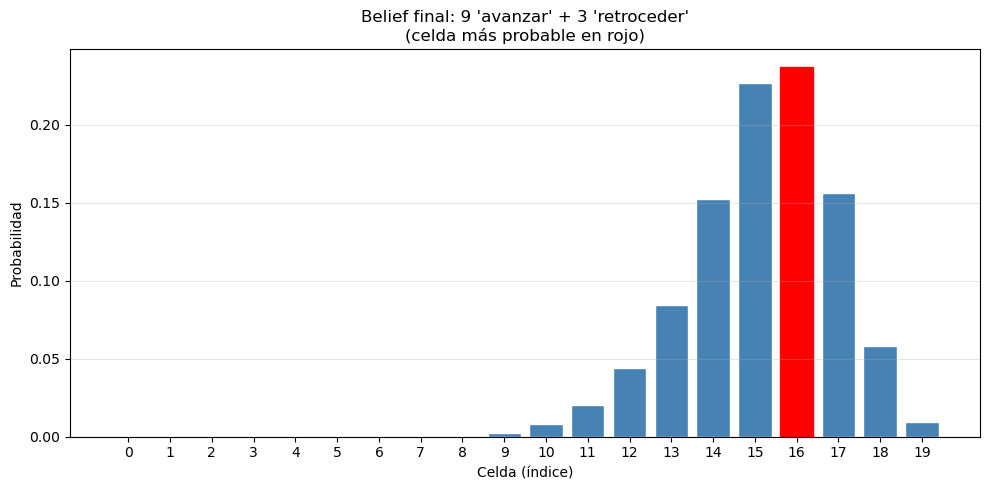

In [12]:
plt.figure(figsize=(10, 5))
bars = plt.bar(np.arange(n), bel, color='steelblue', edgecolor='white')

bars[celda_mas_probable].set_color('red')

plt.xlabel("Celda (índice)")
plt.ylabel("Probabilidad")
plt.title("Belief final: 9 'avanzar' + 3 'retroceder'\n(celda más probable en rojo)")
plt.xticks(np.arange(n))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()